# Sales Forecasting

This notebook loads a sales dataset, converts the `Date` column to datetime, inspects for missing values, and performs basic cleaning. Each code cell includes comments explaining the step.

In [2]:
# 1) Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    plt.style.use('seaborn')  # nicer plots if available
except OSError:
    plt.style.use('default')


In [3]:
# 2) Load the dataset.
# Try the 'data/' folder first, fall back to current directory if not found.
import os
possible_paths = ['data/sales.csv', 'sales.csv']
for p in possible_paths:
    if os.path.exists(p):
        df = pd.read_csv(p)
        print(f'Loaded dataset from {p}')
        break
else:
    raise FileNotFoundError('sales.csv not found in data/ or current directory')

Loaded dataset from data/sales.csv


In [4]:
# 3) Convert the 'Date' column to datetime (coerce invalid values to NaT).
# This ensures downstream time-based operations work correctly.
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    print('Converted Date column to datetime.')
else:
    raise KeyError('Expected a column named "Date" in sales.csv')

Converted Date column to datetime.


In [5]:
# 4) Show the first 5 rows to get a quick look at the data
df.head()

,Date,Product,Sales,Quantity,Region
0,2024-01-01,Widget A,1500.50,10,North
1,2024-01-02,Widget B,2300.75,15,South
2,2024-01-03,Widget A,1800.25,12,East
3,2024-01-04,Widget C,950.00,5,West
4,2024-01-05,Widget B,2150.50,14,North


In [6]:
# 5) Check for null values and a quick info summary
print('DataFrame info:')
df.info()
print('\nNulls per column:')
print(df.isnull().sum())

DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      30 non-null     datetime64[us]
 1   Product   30 non-null     str           
 2   Sales     27 non-null     float64       
 3   Quantity  30 non-null     int64         
 4   Region    30 non-null     str           
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 1.3 KB

Nulls per column:
Date        0
Product     0
Sales       3
Quantity    0
Region      0
dtype: int64


## Cleaning the dataset

The following cell performs basic cleaning: remove exact duplicates, drop rows with entirely empty data, remove rows with invalid/missing dates, and impute missing numeric and categorical values with robust defaults (median/mode). Adjust these rules for your domain as needed.

In [7]:
# 6) Basic cleaning steps
# Drop exact duplicate rows to avoid double-counting
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f'Dropped {before-after} duplicate rows')

# Drop rows that are entirely empty
df = df.dropna(how='all')

# Remove rows with invalid or missing dates since Date is required for time-series forecasting
df = df[~df['Date'].isna()].copy()

# Impute numeric columns with their median (robust to outliers)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    if df[c].isnull().any():
        median = df[c].median()
        df[c] = df[c].fillna(median)
        print(f'Filled missing numeric values in {c} with median={median}')

# Impute object (categorical/text) columns with mode where possible
obj_cols = df.select_dtypes(include=['object']).columns.tolist()
for c in obj_cols:
    if df[c].isnull().any():
        modes = df[c].mode()
        fill = modes.iloc[0] if not modes.empty else ''
        df[c] = df[c].fillna(fill)
        print(f'Filled missing categorical values in {c} with "{fill}"')

Dropped 0 duplicate rows
Filled missing numeric values in Sales with median=1750.25


C:\Users\Gayathri\AppData\Local\Temp\ipykernel_34452\4110943082.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include=['object']).columns.tolist()


In [8]:
# 7) Verify the cleaning results: first 5 rows and null counts
print('First 5 rows after cleaning:')
display(df.head())
print('\nNulls per column after cleaning:')
print(df.isnull().sum())

First 5 rows after cleaning:


,Date,Product,Sales,Quantity,Region
0,2024-01-01,Widget A,1500.50,10,North
1,2024-01-02,Widget B,2300.75,15,South
2,2024-01-03,Widget A,1800.25,12,East
3,2024-01-04,Widget C,950.00,5,West
4,2024-01-05,Widget B,2150.50,14,North



Nulls per column after cleaning:
Date        0
Product     0
Sales       0
Quantity    0
Region      0
dtype: int64


## Basic Statistics and Exploration

Analyze aggregated sales data to understand trends by product and region.


In [9]:
# 8) Group and aggregate sales by date to create time-series data
daily_sales = df.groupby('Date')['Sales'].sum().reset_index()
daily_sales = daily_sales.sort_values('Date').reset_index(drop=True)
print('Daily sales aggregated:')
print(daily_sales.head(10))
print(f'\nTotal records: {len(daily_sales)}')


Daily sales aggregated:
        Date    Sales
0 2024-01-01  1500.50
1 2024-01-02  2300.75
2 2024-01-03  1800.25
3 2024-01-04   950.00
4 2024-01-05  2150.50
5 2024-01-06  1600.75
6 2024-01-07  1050.25
7 2024-01-08  2400.00
8 2024-01-09  1700.50
9 2024-01-10  2200.75

Total records: 30


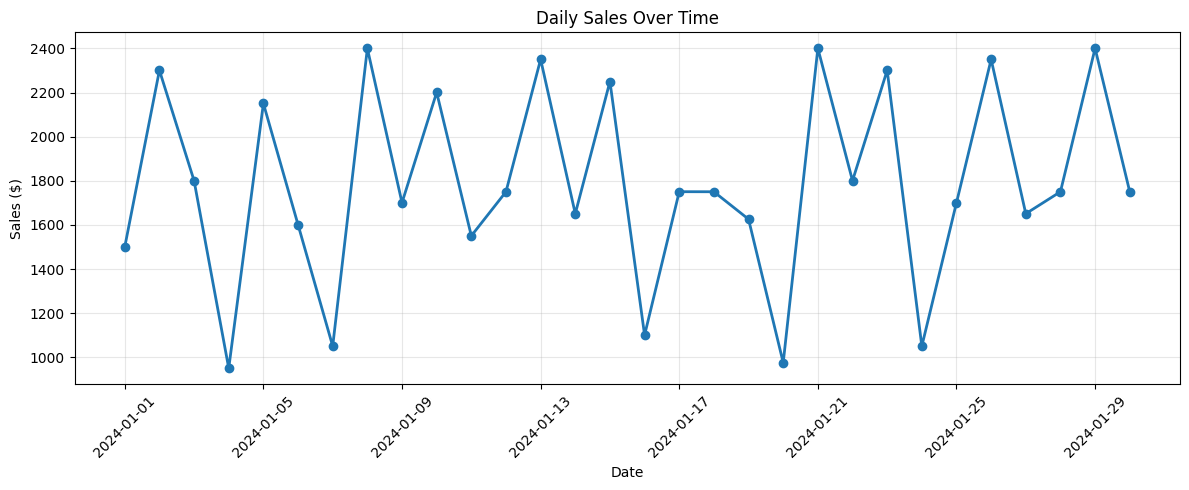

Plot saved to images/ if needed.


In [10]:
# 9) Plot daily sales over time to visualize trends
plt.figure(figsize=(12, 5))
plt.plot(daily_sales['Date'], daily_sales['Sales'], marker='o', linestyle='-', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.title('Daily Sales Over Time')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Plot saved to images/ if needed.')


## Time Features and Trend Visualizations

Create useful time-based features from the aggregated daily sales data and plot both the sales trend and monthly sales totals.

In [11]:
# 10) Create time features from the Date column for analysis
daily_sales['Year'] = daily_sales['Date'].dt.year
daily_sales['Month'] = daily_sales['Date'].dt.month
daily_sales['Day'] = daily_sales['Date'].dt.day
daily_sales['Weekday'] = daily_sales['Date'].dt.day_name()

# Display the new time features to verify they were created correctly
daily_sales[['Date', 'Year', 'Month', 'Day', 'Weekday']].head()

,Date,Year,Month,Day,Weekday
0,2024-01-01,2024,1,1,Monday
1,2024-01-02,2024,1,2,Tuesday
2,2024-01-03,2024,1,3,Wednesday
3,2024-01-04,2024,1,4,Thursday
4,2024-01-05,2024,1,5,Friday


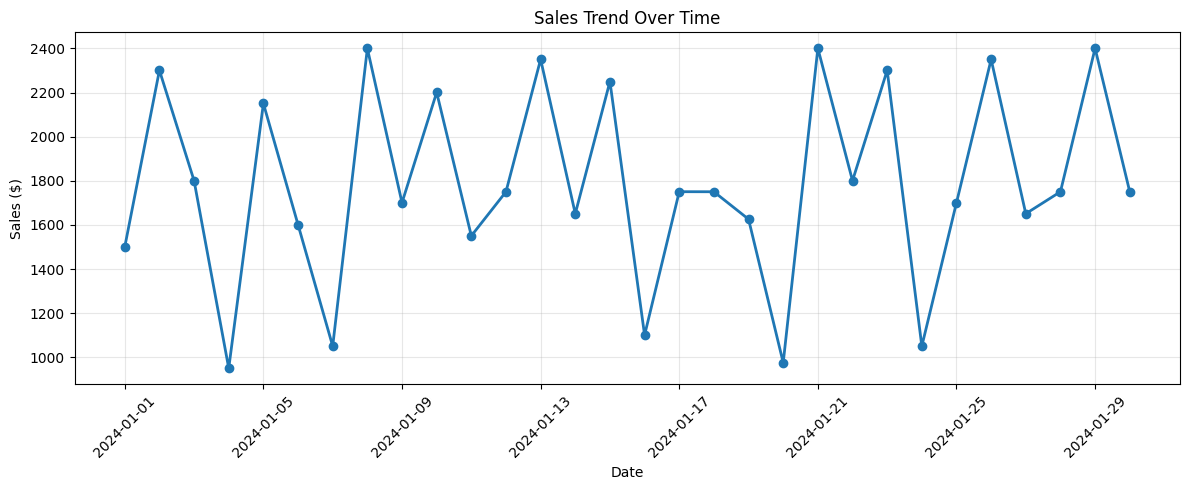

In [12]:
# 11) Plot the sales trend over time using daily sales data
plt.figure(figsize=(12, 5))
plt.plot(daily_sales['Date'], daily_sales['Sales'], marker='o', linestyle='-', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.title('Sales Trend Over Time')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

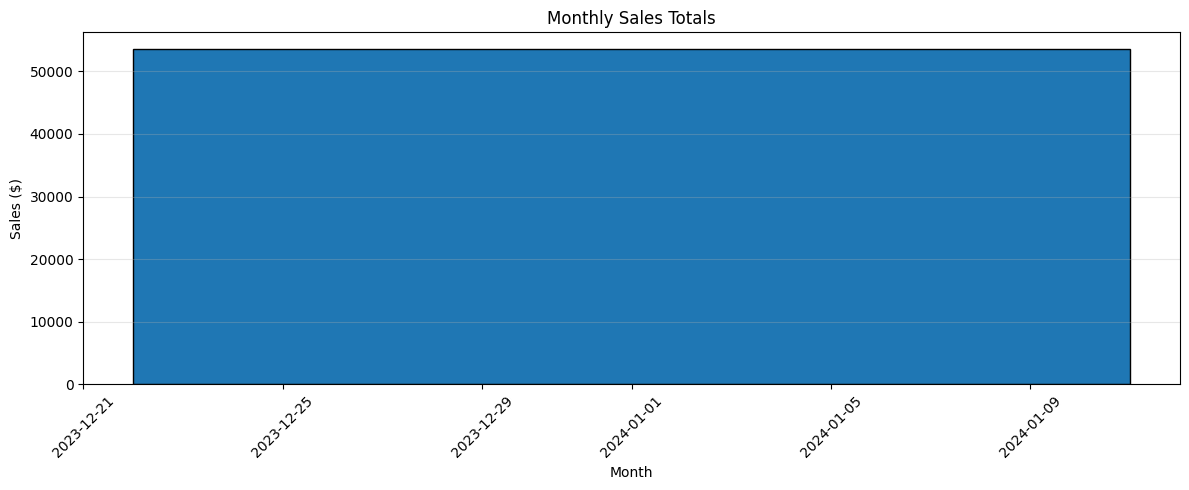

In [13]:
# 12) Create and plot monthly sales totals for a monthly sales chart
monthly_sales = daily_sales.groupby(daily_sales['Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Date'].dt.to_timestamp()

plt.figure(figsize=(12, 5))
plt.bar(monthly_sales['Month'], monthly_sales['Sales'], width=20, edgecolor='black')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.title('Monthly Sales Totals')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Simple Forecasting Model

Use a train/test split and fit a simple linear trend model to predict future sales.


In [14]:
# 10) Prepare data for forecasting: create features and split train/test
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Create a numeric time index to represent each day in the time series
daily_sales['time_index'] = np.arange(len(daily_sales))

# Split into train (80%) and test (20%) sets for model evaluation
split_idx = int(0.8 * len(daily_sales))
train_data = daily_sales[:split_idx]
test_data = daily_sales[split_idx:]

X_train = train_data[['time_index']].values
y_train = train_data['Sales'].values
X_test = test_data[['time_index']].values
y_test = test_data['Sales'].values

# Fit a simple linear regression model to the training data
model = LinearRegression()
model.fit(X_train, y_train)

# Predict sales on the test set
y_pred = model.predict(X_test)

# Calculate model performance metrics
test_mae = mean_absolute_error(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)

# Print the metrics clearly for easy interpretation
print('Linear Regression Model Performance on Test Set')
print('---------------------------------------------')
print(f'Mean Absolute Error (MAE): {test_mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {test_rmse:.2f}')
print(f'R2 Score: {test_r2:.4f}')


Linear Regression Model Performance on Test Set
---------------------------------------------
Mean Absolute Error (MAE): 244.87
Root Mean Squared Error (RMSE): 379.92
R2 Score: -0.4600


Graph saved


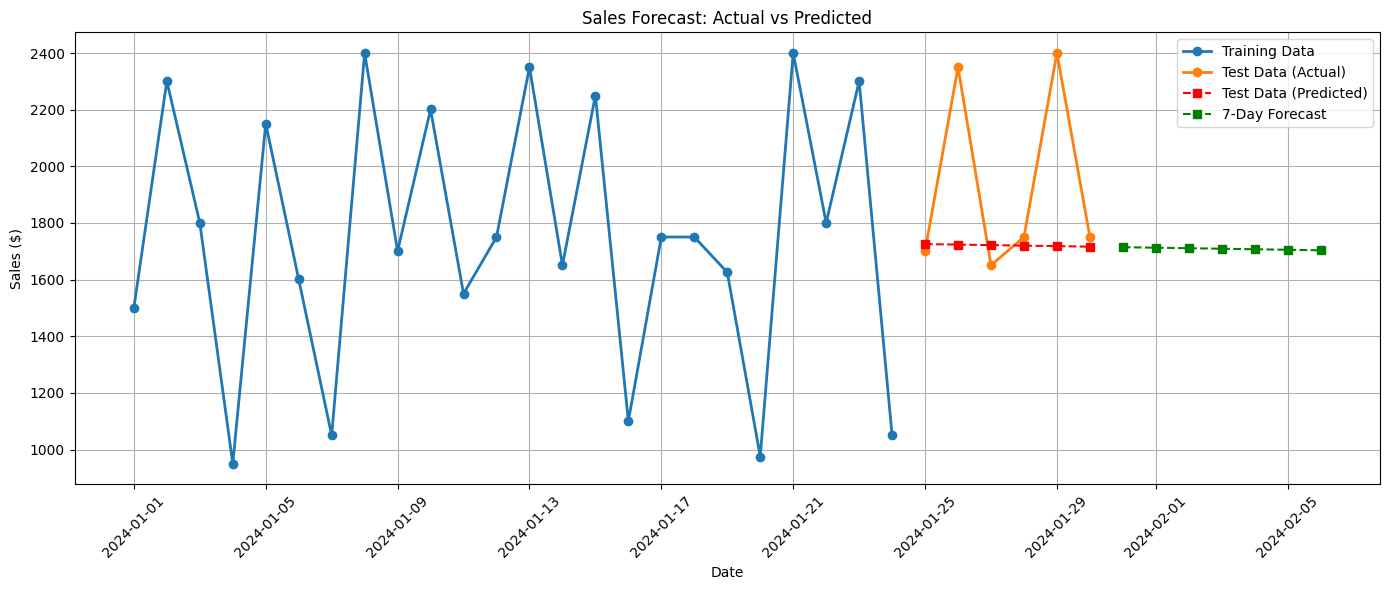

In [15]:
# 11) Plot actual vs. predicted values and forecast the next 7 days

plt.figure(figsize=(14, 6))

# Plot training data
plt.plot(train_data['Date'], y_train, 'o-', label='Training Data', linewidth=2)

# Plot test data
plt.plot(test_data['Date'], y_test, 'o-', label='Test Data (Actual)', linewidth=2)

# Predictions
plt.plot(
    test_data['Date'],
    y_pred,
    's--',
    label='Test Data (Predicted)',
    color='red'
)

# Future forecast
future_indices = np.array([
    [split_idx + len(test_data) + i]
    for i in range(7)
])

future_forecast = model.predict(
    future_indices
)

future_dates = pd.date_range(
    start=test_data['Date'].iloc[-1],
    periods=8,
    freq='D'
)[1:]

plt.plot(
    future_dates,
    future_forecast,
    's--',
    label='7-Day Forecast',
    color='green'
)

plt.xlabel("Date")
plt.ylabel("Sales ($)")

plt.title(
"Sales Forecast: Actual vs Predicted"
)

plt.legend()

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "images/final_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

print("Graph saved")

plt.show()